## Автоэнкодер и их типы

In [1]:
import numpy as np
from keras.datasets import mnist
from keras.layers import Conv2D
%matplotlib inline
import matplotlib.pyplot as plt
from keras import losses
from keras import activations
from keras.layers import Input, Dense, Flatten, Reshape
from keras.models import Model
import tensorflow as tf
import datetime

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

### Сжимающий автоэнкодер

Для начала создадим наиболее простой (сжимающий, undercomplete) автоэнкодер с кодом малой размерности из двух полносвязных слоев: енкодера и декодера.

Так как интенсивность цвета нормирована на единицу, то активацию выходного слоя возьмем сигмоидой.

Напишем отдельные модели для энкодера, декодера и целого автоэнкодера. Для этого создадим экземпляры слоев и применим их один за другим, в конце все объединив в модели.

In [161]:
def create_dense_ae():
    # Размерность скрытого пространства
    encoding_dim = 49

    # Правило связывания слоев:
    # первая скобка - параметры текущего слоя
    # вторая скобка - переменная, которая отвечает за предыдущий слой

    # Энкодер
    # Входной слой
    # 28, 28, 1 - размерности строк, столбцов, фильтров (каналов) одной картинки
    input_img = Input(shape=(28, 28, 1))
    # Вспомогательный слой    
    middle_img = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1))(
        input_img)
    # Кодированное полносвязным слоем представление
    flat_img = Flatten()(middle_img)

    encoded = Dense(encoding_dim, activation='relu')(flat_img)

    # Декодер
    # Раскодированное другим полносвязным слоем изображение
    input_encoded = Input(shape=(encoding_dim,))
    flat_decoded = Dense(10*10, activation='sigmoid')(input_encoded)
    flat2_decoded = Dense(28*28, activation='sigmoid')(flat_decoded)
    decoded = Reshape((28, 28, 1))(flat2_decoded)

    # Модели: в конструктор первым аргументом передаются входные слои, а вторым выходные слои
    encoder = Model(input_img, encoded, name="encoder")
    decoder = Model(input_encoded, decoded, name="decoder")
    autoencoder = Model(input_img, decoder(encoder(input_img)), name="autoencoder")
    return encoder, decoder, autoencoder

Создадим и скомпилируем модель (под компиляцией в данном случае понимается построение графа вычислений обратного распространения ошибки)

In [162]:
encoder, decoder, autoencoder = create_dense_ae()
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

Посмотрим на число параметров

In [163]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 49)             │     2,119,985 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,625 (8.09 MB)

 Trainable params: 2,120,625 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [164]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 100)            │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 784)            │        79,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,184 (328.84 KB)

 Trainable params: 84,184 (328.84 KB)

 Non-trainable params: 0 (0.00 B)

In [165]:
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 49)             │     2,120,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        84,184 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,204,809 (8.41 MB)

 Trainable params: 2,204,809 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

Обучим теперь наш автоэнкодер

In [167]:
log_dir = "logs/autoencoder/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                callbacks=[tensorboard_callback],
                validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - loss: 0.1231 - val_loss: 0.1221
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.1223 - val_loss: 0.1214
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - loss: 0.1215 - val_loss: 0.1207
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - loss: 0.1208 - val_loss: 0.1200
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - loss: 0.1202 - val_loss: 0.1193
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - loss: 0.1195 - val_loss: 0.1188
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - loss: 0.1190 - val_loss: 0.1183
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - loss: 0.1184 - val_loss: 0.1179
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - loss: 0.1178 - val_loss: 0.1174
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - loss: 0.1173 - val_loss: 0.1168


Функция отрисовки цифр

In [8]:
def plot_digits(*args):
    args = [x.squeeze() for x in args]
    n = min([x.shape[0] for x in args])

    plt.figure(figsize=(2 * n, 2 * len(args)))
    for j in range(n):
        for i in range(len(args)):
            ax = plt.subplot(len(args), n, i * n + j + 1)
            plt.imshow(args[i][j])
            plt.gray()
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

    plt.show()

Закодируем несколько изображений и взглянем на пример кода

In [9]:
n = 10

imgs = x_test[:n]  # первые 10 картинок
encoded_imgs = encoder.predict(imgs, batch_size=n)  # получить скрытые значения (вектор 49 чисел) для первых 10 картинок
encoded_imgs[0]  # посмотреть на первую картинку (вектор значений)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


array([ 0.      , 91.91018 ,  0.      ,  0.      , 23.322178,  0.      ,
       56.724686,  0.      ,  0.      , 54.2474  ,  0.      ,  0.      ,
       40.113262,  0.      , 21.440247, 30.822416, 37.214725, 32.02285 ,
       24.213552,  0.      , 21.059792,  0.      ,  0.      , 35.616524,
        0.      , 19.618645,  0.      , 68.660965,  0.      , 54.494793,
       25.727154,  0.      ,  0.      , 18.807682,  0.      ,  0.      ,
       38.927654, 31.950573, 30.53994 ,  0.      , 27.542215, 29.8793  ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ], dtype=float32)

Декодируем эти коды и сравним с оригиналами

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


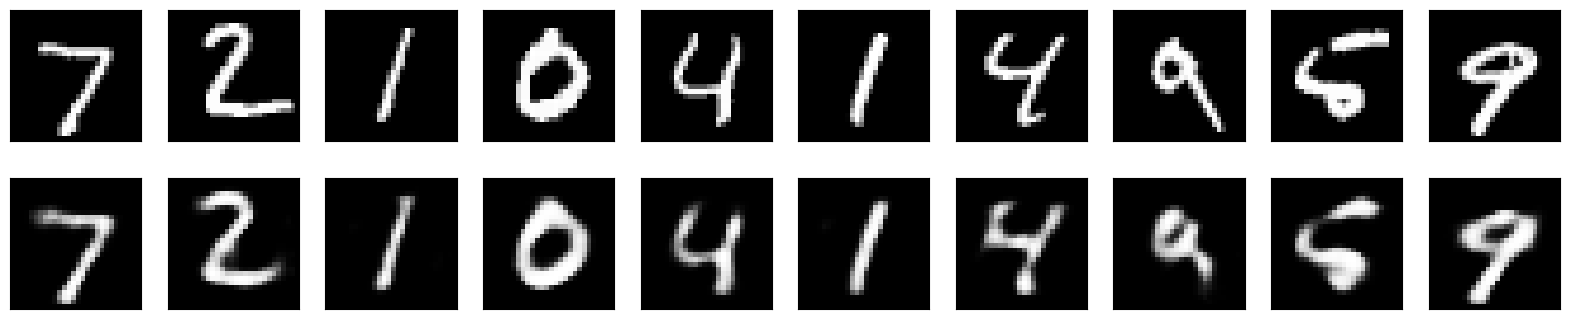

In [10]:
decoded_imgs = decoder.predict(encoded_imgs, batch_size=n)

plot_digits(imgs, decoded_imgs)  # исходные и обработанные картинки

### Задания

С использованием приведенных сведений студентам надлежит:

* обучить на MNIST автокодировщик (мы провели обучение на 10 эпохах, попробовать другое значение, можно ли лучше?);
* получить векторы всех изображений MNIST с выхода кодера;
* использовать полученные векторы в качестве входных для обучения нейронной сети – классификатора рукописных цифр;
* сравнить точности классификации, получаемые нейронной сетью, обученными на изображениях MNIST и на векторах, снятых с выхода кодера автокодировщика.

In [11]:
# Ваш код


In [90]:
x_enc_train = encoder.predict(x_train,
                              batch_size=600)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [91]:
x_enc_test = encoder.predict(x_test, batch_size=len(x_test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


In [132]:
encoding_dim = 49

def create_classifier():
    # Размерность скрытого пространства
    input_encoded = Input(shape=(encoding_dim,))
    dense1 = Dense(28, activation=activations.relu)(input_encoded)
    dense2 = Dense(128, activation=activations.relu)(dense1)
    dense3 = Dense(28, activation=activations.relu)(dense2)
    output_classes = Dense(10, activation=activations.softmax)(dense3)

    # Модели: в конструктор первым аргументом передаются входные слои, а вторым выходные слои
    classifier = Model(input_encoded, output_classes, name="classifier")
    return classifier

In [133]:
classifier = create_classifier()
classifier.compile(optimizer='adam', loss=losses.sparse_categorical_crossentropy, metrics=["accuracy"])

In [134]:
classifier.summary()

Model: "classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 28)             │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 28)             │         3,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 10)             │           290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,014 (35.21 KB)

 Trainable params: 9,014 (35.21 KB)

 Non-trainable params: 0 (0.00 B)

In [135]:
log_dir = "logs/classify/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
classifier.fit(x_enc_train, y_train,
                epochs=200,
                batch_size=256,
                shuffle=True,
                callbacks=[tensorboard_callback],
                validation_data=(x_enc_test, y_test))

Epoch 1/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6919 - loss: 1.4539 - val_accuracy: 0.8689 - val_loss: 0.4269
Epoch 2/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8879 - loss: 0.3610 - val_accuracy: 0.9097 - val_loss: 0.2860
Epoch 3/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9139 - loss: 0.2769 - val_accuracy: 0.9227 - val_loss: 0.2419
Epoch 4/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9266 - loss: 0.2324 - val_accuracy: 0.9347 - val_loss: 0.2019
Epoch 5/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9357 - loss: 0.2034 - val_accuracy: 0.9417 - val_loss: 0.1895
Epoch 6/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9420 - loss: 0.1842 - val_accuracy: 0.9458 - val_loss: 0.1735
Epoch 7/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9464 - loss: 0.1720 - val_accuracy: 0.9509 - val_loss: 0.1541
Epoch 8/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9492 - loss: 0.1623 - val_accu

KeyboardInterrupt: 

In [156]:
test_loss, test_accuracy = classifier.evaluate(x_enc_test, y_test, batch_size=256, verbose=2)

40/40 - 0s - 7ms/step - accuracy: 0.9710 - loss: 0.1427


In [157]:
x_autoencoder_train = autoencoder.predict(x_train,
                              batch_size=600)

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


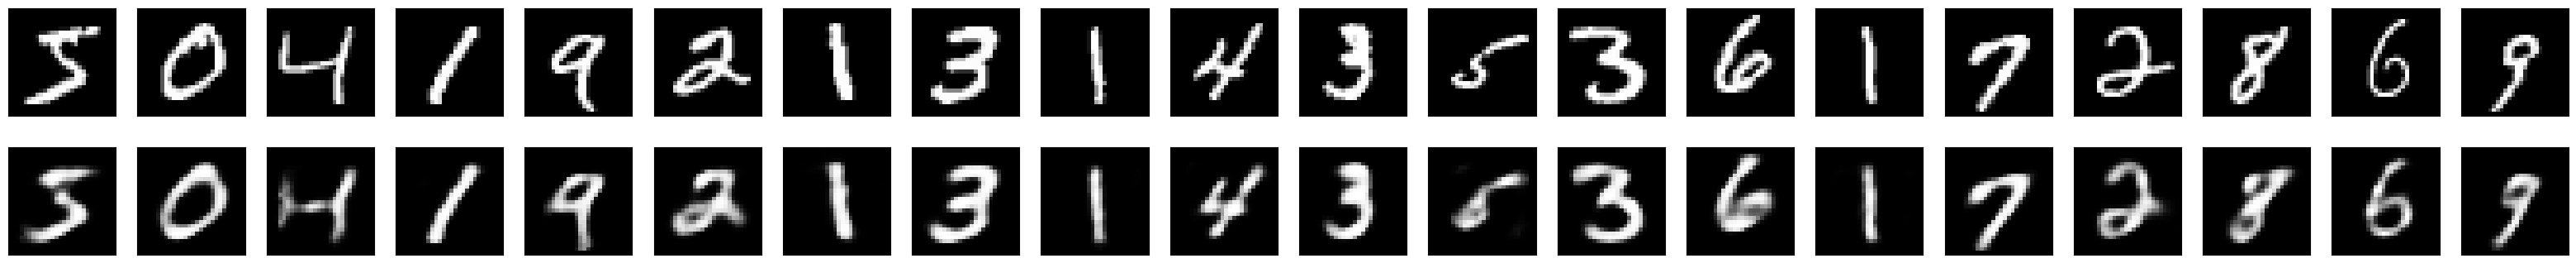

In [158]:
plot_digits(x_train[:20], x_autoencoder_train[:20])